# Marketing Campaign Analysis: Customer Response Insights

### Identifying Customer Characteristics Associated with Campaign Response

**By Zahra Sahebari**

*MSc Business Analytics | Python | SQL | Data Analytics*

---

This project analyses customer response to a marketing campaign using Python and statistical analysis. The objective is to identify customer characteristics associated with campaign response and translate the findings into actionable business recommendations for future marketing campaigns.

## Business Context

Successful marketing campaigns depend on identifying and targeting customers who are most likely to respond. Organisations increasingly rely on customer data to improve campaign effectiveness, optimise marketing expenditure, and maximise return on investment (ROI).

This project analyses customer demographic, purchasing, and behavioural data to identify the characteristics associated with campaign response. The findings aim to support data-driven marketing decisions and provide recommendations for improving future campaign performance.

## Business Objectives

The objective of this analysis is to evaluate the effectiveness of a marketing campaign and identify the customer characteristics associated with campaign response.

Specifically, this project aims to answer the following business questions:

1. How successful was the marketing campaign?

2. Do higher-income customers respond more frequently to the marketing campaign?

3. Does customer age influence campaign response?

4. Does education level influence campaign response?

5. Does marital status influence campaign response?

6. What customer characteristics are associated with a higher likelihood of campaign response?

7. Based on the findings, what recommendations can improve future marketing campaigns?

## Executive Summary

This report presents an exploratory and statistical analysis of a marketing campaign conducted in 2014 to identify the customer characteristics associated with campaign response. The original dataset contained 2,240 customer records. After data cleaning, 24 observations with missing income values were removed, resulting in a final dataset of 2,216 customers for analysis.

The analysis combined exploratory data analysis with inferential statistical tests to evaluate whether differences observed in customer response were statistically significant. The results indicated that customer income, education level, and marital status were significantly associated with campaign response, whereas customer age did not show a statistically significant relationship with campaign response when analysed individually.

Based on these findings, future marketing campaigns should prioritise higher-income customer segments and consider education level and marital status when developing customer segmentation strategies. Age, however, should not be used as a primary targeting criterion. Future analyses could extend this work by investigating the combined effects of multiple customer characteristics using predictive modelling techniques.

### Analytical Approach

The analysis follows a structured business analytics workflow consisting of:

- Data understanding
- Data cleaning
- Data validation
- Exploratory data analysis
- Statistical validation (later section)
- Business recommendations

## Data Acquisition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "/kaggle/input/datasets/imakash3011/customer-personality-analysis/marketing_campaign.csv",
    sep = "\t"
    )
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### Observation

The dataset was successfully imported into a Pandas DataFrame. A review of the first five observations confirms that the variables have been loaded correctly and are ready for further exploration.

## Data Understanding

In [3]:
df.shape

(2240, 29)

### Observation

The dataset contains **2,240 customer records** and **29 variables**, providing a sufficiently large sample for exploratory data analysis.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

### Observation

The dataset contains a mixture of numerical and categorical variables describing customer demographics, purchasing behaviour, and campaign outcomes. Only the **Income** variable contains missing values (24 observations), while all remaining variables are complete.

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

### Observation

Missing values are present only in the **Income** variable, representing approximately **1.1%** of the dataset. Given the small proportion of missing observations, removing these records is unlikely to materially affect the overall analysis.

In [6]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


### Observation

The summary statistics provide an overview of the numerical variables within the dataset. The **Income** variable exhibits a substantial range, with the maximum value considerably exceeding the upper quartile, suggesting the presence of potential outliers that warrant further investigation.

## Data Cleaning

### Missing Values

A data quality assessment identified missing values only in the **Income** variable. As income is a key explanatory variable in this analysis, an appropriate treatment strategy is required before proceeding with exploratory data analysis.

In [7]:
df = df.dropna(subset = ["Income"])

### Observation

Records containing missing values in the **Income** variable were removed from the dataset. As only **24 observations (approximately 1.1%)** contained missing income values, this decision has a negligible impact on the overall sample size.

### Analyst's Note

Income is a key explanatory variable in this analysis. Rather than introducing artificial values through imputation, the incomplete observations were removed to preserve the integrity of the dataset and ensure that subsequent analyses are based on observed customer information.

In [8]:
df.shape

(2216, 29)

### Duplicate Records

Duplicate observations can distort summary statistics and lead to biased analytical results. Therefore, the dataset is examined to determine whether duplicate customer records are present before proceeding with further analysis.

In [9]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were identified in the dataset. Each row represents a unique customer, indicating that duplicate observations are not expected to influence the analysis.

### Analyst's Note

Since no duplicate records were detected, no further cleaning was required at this stage. The dataset can therefore be considered structurally consistent with respect to duplicate observations.

## Data Validation

### Outlier Assessment

Summary statistics suggested the presence of unusually large income values. Before conducting exploratory data analysis, the **Income** variable is examined to determine whether these observations represent genuine customer records or potential data quality issues.

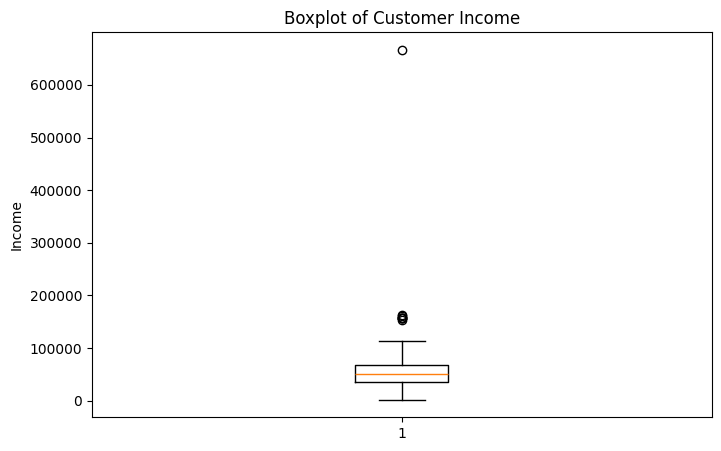

In [10]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Income"])
plt.title("Boxplot of Customer Income")
plt.ylabel("Income")
plt.show()

### Observation

The box plot indicates the presence of several high-income observations beyond the upper whisker, including one observation substantially higher than the remainder of the distribution. This suggests that the **Income** variable contains potential outliers and exhibits a positively (right) skewed distribution.

### Analyst's Note

The identified observations were investigated visually. However, no evidence suggests that these values are the result of data entry errors or inconsistencies. As they may represent genuine high-income customers, the outliers have been retained to preserve the integrity and representativeness of the dataset.

In [11]:
df[df["Income"] == df["Income"].max()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2233,9432,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,...,6,0,0,0,0,0,0,3,11,0


### Decision

The customer record associated with the highest income value was reviewed to assess whether the observation represented a potential data quality issue. The available demographic information appeared internally consistent, and no evidence suggested that the record resulted from a data entry error.

Consequently, the identified outliers were retained for the remainder of the analysis.

# Exploratory Data Analysis

## Business Question 1

### How successful was the marketing campaign?

### Business Motivation

Before analysing which customer characteristics influence campaign response, it is important to understand the overall effectiveness of the marketing campaign. Establishing the baseline response rate provides context for all subsequent analyses.

### Analytical Method

The campaign response variable is analysed by calculating both the number and percentage of customers who accepted and did not accept the marketing campaign. This establishes the baseline campaign performance before investigating customer characteristics.

In [12]:
df["Response"].value_counts()

Response
0    1883
1     333
Name: count, dtype: int64

In [13]:
response_rate = (
    df["Response"].value_counts(normalize=True)
    .mul(100)
    .round(2)
)
response_rate

Response
0    84.97
1    15.03
Name: proportion, dtype: float64

### Observation

Approximately **84.97%** of customers did not respond to the marketing campaign, while only **15.03%** accepted the offer.

### Interpretation

The response rate is relatively low, with only around one in every seven customers accepting the campaign offer. This suggests that the campaign reached many customers who were not interested or that the targeting strategy could potentially be improved.

### Business Insight

Improving customer targeting could increase campaign effectiveness and reduce unnecessary marketing expenditure. The following analyses investigate whether customer characteristics such as income, age, education, and marital status are associated with campaign response.

## Business Question 2

### Do higher-income customers respond more frequently to the marketing campaign?

### Business Motivation

Customer income is often associated with purchasing power and spending behaviour. Understanding whether higher-income customers are more likely to respond to marketing campaigns can help organisations improve customer targeting and allocate marketing resources more effectively.

### Analytical Hypothesis

It is hypothesised that higher-income customers are more likely to respond to the marketing campaign than lower-income customers.

### Analytical Method

The analysis compares the income distributions of customers who responded to the marketing campaign with those who did not. Descriptive statistics are used to identify differences in average income and overall income distribution between the two groups.

In [14]:
df.groupby("Response")["Income"].describe()

,count,mean,std,min,25%,50%,75%,max
Response,,,,,,,,
0,1883.0,50839.132767,25252.804747,1730.0,34421.0,50150.0,66308.0,666666.0
1,333.0,60209.675676,23194.080987,7500.0,39763.0,64090.0,80589.0,105471.0


### Observation

Customers who responded to the marketing campaign had a higher average income (£60,210) than customers who did not respond (£50,839). The median income also differed between the two groups, with responders exhibiting a median income of £64,090 compared with £50,150 for non-responders.

### Interpretation

The descriptive statistics suggest that customers with higher incomes were more likely to respond to the marketing campaign. Both the mean and median income are higher among responders, indicating a consistent difference between the two groups rather than one driven solely by extreme values.

### Visual Comparison

<Figure size 800x500 with 0 Axes>

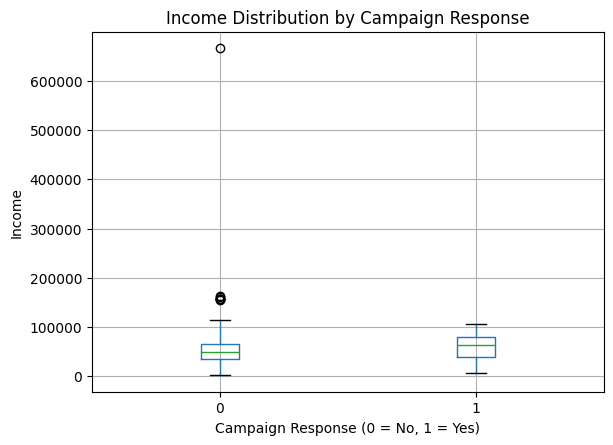

In [15]:
plt.figure(figsize=(8,5))
df.boxplot(column="Income", by="Response")
plt.title("Income Distribution by Campaign Response")
plt.suptitle("")
plt.ylabel("Income")
plt.xlabel("Campaign Response (0 = No, 1 = Yes)")
plt.show()

### Interpretation

Both the descriptive statistics and the grouped box plot indicate that customers who responded to the marketing campaign generally have higher incomes than those who did not respond. The higher median income among responders suggests that this pattern reflects the overall income distribution rather than being driven by a small number of extreme observations.

### Business Insight

Income appears to be an important customer characteristic when considering campaign targeting. Prioritising higher-income customer segments may improve campaign response rates and increase the efficiency of future marketing activities.

### Conclusion

The descriptive analysis supports the hypothesis that higher-income customers are more likely to respond to the marketing campaign. However, statistical testing will be conducted later in the analysis to determine whether the observed difference is statistically significant.

## Business Question 3
### Does customer age influence campaign response?

### Business Motivation

Customer age often influences purchasing behaviour, product preferences, and responsiveness to marketing campaigns. Understanding whether age is associated with campaign response can help organisations design more targeted and effective marketing strategies.

### Analytical Hypothesis

The previous analysis indicated that higher-income customers were more likely to respond to the marketing campaign. Since age may influence income and purchasing behaviour, it is hypothesised that customer age may also be associated with campaign response.

### Analytical Method

Since the dataset contains customers' year of birth rather than age, a new variable representing customer age will first be created. The age distributions of responders and non-responders will then be compared using descriptive statistics and visualisation.

In [16]:
df["Age"] = 2014 - df["Year_Birth"]
df[["Age", "Year_Birth"]].head()

,Age,Year_Birth
0,57,1957
1,60,1954
2,49,1965
3,30,1984
4,33,1981


In [17]:
df.groupby("Response")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Response,,,,,,,,
0,1883.0,45.298991,11.922676,18.0,37.0,44.0,55.0,121.0
1,333.0,44.504505,12.331667,18.0,35.0,43.0,55.0,71.0


### Observation
Customers who responded to the marketing campaign had a slightly lower average age (44.5 years) than customers who did not respond (45.3 years). The median ages were also very similar, at 43 and 44 years respectively. Additionally, the non-responder group contains a maximum age of 121 years, which appears substantially higher than the rest of the distribution.

### Interpretation
The descriptive statistics suggest that customer age is not strongly associated with campaign response. Although the mean age of non-responders is slightly higher, the difference is less than one year. Furthermore, the similarity in median ages indicates that the overall age distributions are highly comparable and that the observed difference is unlikely to be driven by meaningful variation between the two groups.

In [18]:
df[df["Age"] == df["Age"].max()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
239,11004,1893,2n Cycle,Single,60182.0,0,1,17-05-2014,23,8,...,0,0,0,0,0,0,3,11,0,121


### Visual Comparison

<Figure size 800x600 with 0 Axes>

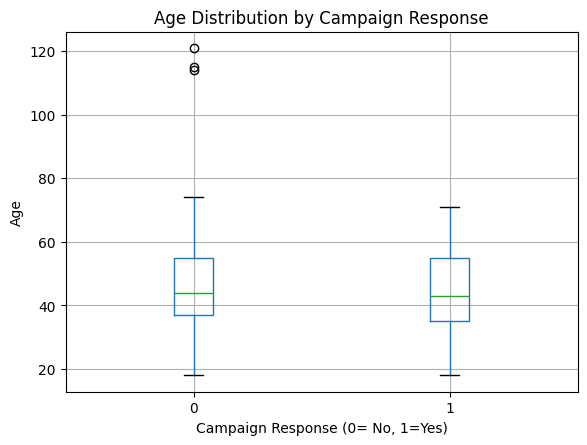

In [19]:
plt.figure(figsize = (8,6))
df.boxplot(column= "Age", by= "Response")
plt.title("Age Distribution by Campaign Response")
plt.suptitle("")
plt.xlabel("Campaign Response (0= No, 1=Yes)")
plt.ylabel("Age")

plt.show()

### Observation

The box plots for responders and non-responders are highly similar. Both groups exhibit comparable median ages, interquartile ranges, and whisker lengths. The non-responder group contains several high-age outliers, including one customer aged 121 years.

### Interpretation

The box plot supports the descriptive statistics, indicating that the age distributions of responders and non-responders are very similar. The presence of several high-age outliers increases the maximum age among non-responders but does not materially affect the overall distribution. Therefore, age does not appear to strongly distinguish customers who responded to the campaign from those who did not.

### Data Quality Note

One customer record corresponds to an age of 121 years, which appears unusual and may represent a data entry error or another data quality anomaly. However, this observation represents only one customer (approximately 0.05% of the dataset). Furthermore, the similarity in median ages between responders and non-responders indicates that this observation does not materially influence the overall findings. Therefore, the record was retained to preserve the integrity of the original dataset.

### Business Insight
The analysis suggests that customer age alone is unlikely to be an effective variable for customer segmentation in future marketing campaigns. Unlike income, which exhibited noticeable differences between responders and non-responders, age distributions were highly similar across both groups. This indicates that marketers should prioritise other customer characteristics when designing targeted campaigns.

### Conclusion

The descriptive analysis does not support the analytical hypothesis that customer age is meaningfully associated with campaign response. Both the descriptive statistics and the box plot indicate that responders and non-responders have very similar age distributions. Therefore, age does not appear to be a strong predictor of campaign response within this dataset. This finding should be confirmed through statistical testing in a later section.

## Business Question 4

### Does education level influence campaign response?

### Business Motivation

Education level may influence consumer behaviour, purchasing preferences, and responsiveness to marketing campaigns. Identifying differences in campaign response across education groups can help organisations better understand their customer segments and develop more targeted marketing strategies.

### Analytical Hypothesis

It is hypothesised that campaign response differs across education levels.

### Analytical Method

The relationship between education level and campaign response is examined using a contingency table. The number of responders and non-responders is first compared across education levels, followed by response percentages to account for differences in group sizes.

In [20]:
pd.crosstab(df["Education"], df["Response"])

Response,0,1
Education,,
2n Cycle,178,22
Basic,52,2
Graduation,964,152
Master,309,56
PhD,380,101


In [21]:
education_rate = (
    pd.crosstab(
        df["Education"],
        df["Response"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

education_rate

Response,0,1
Education,,
2n Cycle,89.00,11.00
Basic,96.30,3.70
Graduation,86.38,13.62
Master,84.66,15.34
PhD,79.00,21.00


### Observation

The response rate differs across education levels. Customers with a PhD exhibited the highest response rate (21.00%), followed by those with a Master's degree (15.34%) and Graduation (13.62%). Customers with Basic education had the lowest response rate (3.70%).

### Interpretation

The response percentages suggest that customers with higher levels of education were generally more likely to respond to the marketing campaign. In particular, customers holding a PhD responded at a noticeably higher rate than the other education groups, whereas customers with Basic education exhibited the lowest response rate.

### Visual Comparison

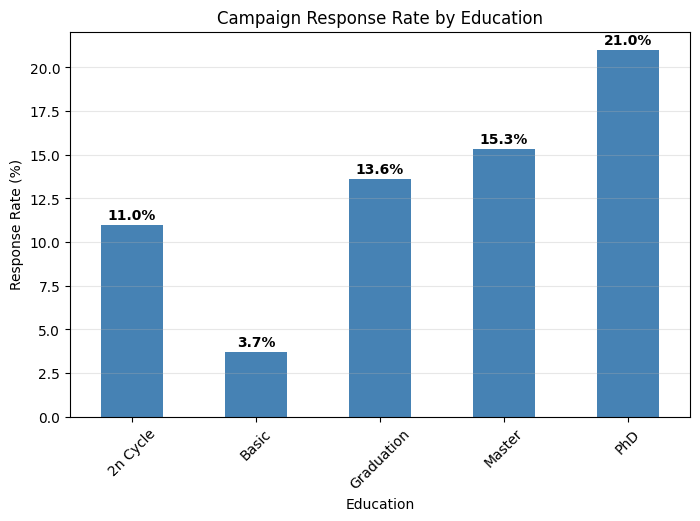

In [22]:
plt.figure(figsize=(8,5))
ax = education_rate[1].plot(
        kind="bar",
        color = "steelblue",
        rot = 45
    )
plt.title("Campaign Response Rate by Education")
plt.xlabel("Education")
plt.ylabel("Response Rate (%)")
plt.grid(axis="y", alpha = 0.3)

for i, value in enumerate(education_rate[1]):
    ax.text(
        i,
        value + 0.3,
        f"{value:.1f}%",
        ha= "center",
        fontsize = 10,
        fontweight = "bold"
    )
    
plt.show()

### Observation

The response rate varies across education levels. Customers with a PhD exhibited the highest response rate (21.0%), followed by Master's degree holders (15.3%) and Graduates (13.6%). Customers with Basic education had the lowest response rate (3.7%), while customers with a 2n Cycle education had a response rate of 11.0%.

### Interpretation

The bar chart reinforces the findings from the response rate table. Customers with higher educational attainment generally exhibited higher campaign response rates than those with lower educational attainment. This suggests that education level may be associated with campaign responsiveness.

### Business Insight

Education level appears to be a valuable characteristic for customer segmentation. Marketing campaigns targeted towards customers with higher educational attainment may achieve higher response rates and improve the efficiency of marketing resources.

### Conclusion

The descriptive analysis supports the analytical hypothesis that campaign response differs across education levels. Customers with higher educational attainment generally exhibited higher response rates than customers with lower educational attainment. This finding should be confirmed through statistical testing in a later section.

## Business Question 5

### Does marital status influence campaign response?

### Business Motivation

Marital status may influence household income, purchasing behaviour, and spending priorities. Understanding whether campaign response differs across marital status groups can help organisations identify customer segments that are more receptive to marketing campaigns and improve future targeting strategies.

### Analytical Hypothesis

It is hypothesised that campaign response differs across marital status groups.

### Analytical Method

The relationship between marital status and campaign response is examined using contingency tables and response rates. The number of responders and non-responders is first compared across marital status groups, followed by response percentages to account for differences in group sizes.

In [23]:
pd.crosstab(df["Marital_Status"], df["Response"])

Response,0,1
Marital_Status,,
Absurd,1,1
Alone,2,1
Divorced,184,48
Married,759,98
Single,365,106
Together,513,60
Widow,58,18
YOLO,1,1


The frequency table indicates that some marital status categories contain very few observations. These categories are reviewed before calculating response rates to ensure meaningful comparisons across customer groups.

### Data Quality Note

Three marital status categories (Absurd, Alone, and YOLO) contain only seven customers in total. Due to the extremely small sample size, these categories were excluded from the comparative analysis to avoid drawing unreliable conclusions. The original dataset was not modified.

In [24]:
marital_df = df[ 
    ~df["Marital_Status"].isin(["Absurd", "Alone", "YOLO"])
]

In [25]:
pd.crosstab(marital_df["Marital_Status"], marital_df["Response"])

Response,0,1
Marital_Status,,
Divorced,184,48
Married,759,98
Single,365,106
Together,513,60
Widow,58,18


In [26]:
marital_response_rate = (
    pd.crosstab(
        marital_df["Marital_Status"],
        marital_df["Response"],
        normalize = "index"
    )
    .mul(100)
    .round(2)
)

marital_response_rate

Response,0,1
Marital_Status,,
Divorced,79.31,20.69
Married,88.56,11.44
Single,77.49,22.51
Together,89.53,10.47
Widow,76.32,23.68


### Visual Comparison

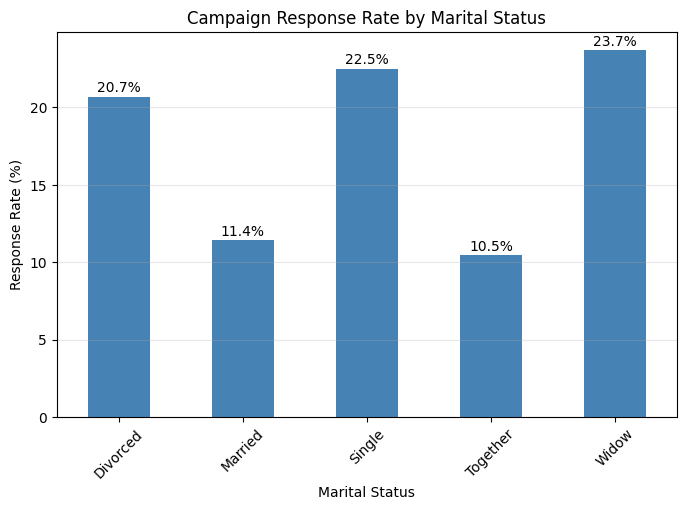

In [27]:
plt.figure(figsize=(8,5))
ax = marital_response_rate[1].plot(
    kind = "bar",
    color = "steelblue",
    rot = 45
)
plt.title("Campaign Response Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Response Rate (%)")
plt.grid(axis = "y", alpha = 0.3)

for i, value in enumerate(marital_response_rate[1]):
    ax.text(i, value + 0.3, f"{value:.1f}%", ha="center")

plt.show()

### Observation

The response rate differs across marital status groups. Widowed customers exhibited the highest response rate (23.7%), followed closely by Single (22.5%) and Divorced (20.7%) customers. Married and Together customers had considerably lower response rates of 11.4% and 10.5%, respectively.

### Interpretation

The descriptive analysis suggests that marital status may be associated with campaign response. Customers who were Single, Divorced, or Widowed responded to the campaign more frequently than customers who were Married or Together. This indicates that household composition or lifestyle differences may influence campaign responsiveness.

### Business Insight

Marital status appears to provide useful information for customer segmentation. Marketing campaigns tailored towards Single, Divorced, and Widowed customers may achieve higher response rates than campaigns targeting Married or Together customers.

### Conclusion

The descriptive analysis supports the analytical hypothesis that campaign response differs across marital status groups. Customers who were Single, Divorced, and Widowed generally exhibited higher response rates than customers who were Married or Together. This finding should be confirmed through statistical testing in a later section.

## Business Question 6

### What customer characteristics are associated with a higher likelihood of campaign response?

### Business Motivation

Marketing campaigns are most effective when organisations understand which customer characteristics are associated with higher response rates. By comparing the findings across all previous analyses, it is possible to identify the characteristics that appear to be the strongest indicators of campaign success and support future customer targeting strategies.

### Analytical Method

The findings from the previous analyses are compared to evaluate the relative importance of income, age, education level, and marital status. Rather than analysing a single variable, this section synthesises the descriptive results to identify which customer characteristics appear to have the strongest association with campaign response.

### Summary of Findings

| Customer Characteristic | Summary of Evidence |
|-------------------------|---------------------|
| Income | Responders had higher average and median income than non-responders. |
| Age | Very little difference was observed between responders and non-responders. |
| Education | Response rates generally increased with higher educational attainment. |
| Marital Status | Response rates were higher among Single, Divorced, and Widowed customers than among Married and Together customers. |

### Interpretation

The descriptive analyses indicate that income, education level, and marital status exhibit more noticeable differences between responders and non-responders than age. While income differs in terms of average and median values, education level and marital status show variation in response rates across customer groups. In contrast, age distributions are highly similar between responders and non-responders, suggesting that age may be less informative for customer segmentation.

### Business Insight

The findings suggest that organisations may achieve more effective customer targeting by considering income, education level, and marital status when designing future marketing campaigns. In contrast, age alone appears to provide limited additional value for customer segmentation within this dataset.

### Conclusion

Among the customer characteristics examined, income, education level, and marital status appear to be more strongly associated with campaign response than age. These findings are based on descriptive analysis and provide an evidence-based foundation for the statistical validation presented in the next section.

# Statistical Validation

The exploratory data analysis identified several customer characteristics that appeared to differ between responders and non-responders. However, descriptive analysis alone cannot determine whether these observed differences are statistically significant or may have occurred by chance.

This section applies appropriate statistical tests to evaluate the statistical significance of the observed relationships and provide stronger evidence for the conclusions drawn from the exploratory analysis.

## Statistical Analysis Plan

The statistical tests were selected according to the type of variables being analysed.

- Independent Samples t-test was used to compare the mean values of continuous variables (Income and Age) between responders and non-responders.
- Chi-Square Test of Independence was used to examine the association between categorical variables (Education and Marital Status) and campaign response.
- A significance level of 5% (α = 0.05) was adopted throughout the analysis. P-values below 0.05 were considered statistically significant.

## Statistical Test 1

### Is customer income significantly associated with campaign response?

### Business Motivation

The exploratory data analysis suggested that customers who responded to the marketing campaign had higher incomes than those who did not respond. However, descriptive statistics alone cannot determine whether the observed difference is statistically significant or could have occurred by chance. Therefore, a statistical test is conducted to evaluate whether the difference in average income between the two groups is statistically significant.

### Statistical Hypotheses

H₀ (Null Hypothesis):
There is no difference in the average income of responders and non-responders.

H₁ (Alternative Hypothesis):
There is a difference in the average income of responders and non-responders.

### Choice of Statistical Test

Income is a continuous numerical variable, while campaign response consists of two independent groups (responders and non-responders). Therefore, an Independent Samples t-test is an appropriate statistical method for comparing the average income between the two groups.

### Assumption Checks

The Independent Samples t-test assumes that observations are independent, the sampling distribution of the mean is approximately normal, and the variances of the two groups are considered when selecting the appropriate version of the test.

Each observation in the dataset represents a different customer, so the independence assumption is considered satisfied. Although income is not perfectly normally distributed, both groups contain large sample sizes (1,883 non-responders and 333 responders). According to the Central Limit Theorem, the sampling distribution of the mean is expected to be approximately normal, making the t-test appropriate.

Because the sample sizes are unequal and equal population variances cannot be assumed, Welch's Independent Samples t-test is applied (`equal_var=False`).

In [28]:
from scipy.stats import ttest_ind
income_non_response = df[df["Response"] == 0]["Income"]
income_response = df[df["Response"] == 1]["Income"]

t_statistic , p_value = ttest_ind(
    income_non_response,
    income_response,
    equal_var = False
)

print(f"T-statistic: {t_statistic: .3f}")
print(f"P_Value: {p_value: .4f}")

T-statistic: -6.703
P_Value:  0.0000


### Results

Welch's Independent Samples t-test indicated a statistically significant difference in average income between responders and non-responders (t = -6.703, p < 0.001).

### Interpretation

The p-value is substantially smaller than the significance level of 0.05. Therefore, the null hypothesis is rejected.

The analysis provides strong statistical evidence that the average income differs between customers who responded to the marketing campaign and those who did not respond. This finding supports the pattern observed during the exploratory data analysis, where responders exhibited higher average and median incomes than non-responders.

### Business Insight

Income appears to be a statistically significant characteristic associated with campaign response. Customers with higher incomes may represent a valuable target segment for future marketing campaigns, although this analysis demonstrates association rather than causation.

### Conclusion

The statistical analysis confirms that the difference in average income between responders and non-responders is unlikely to have occurred by chance. Therefore, income should be considered an important customer characteristic when designing future marketing campaigns.

## Statistical Test 2

### Is customer age significantly associated with campaign response?

### Business Motivation

The exploratory data analysis indicated only a small difference in the average age of responders and non-responders. A statistical test is therefore conducted to determine whether the observed difference is statistically significant or could have occurred by chance.

### Statistical Hypotheses

H₀ (Null Hypothesis)

There is no difference in the average age of responders and non-responders.

H₁ (Alternative Hypothesis)

There is a difference in the average age of responders and non-responders.

### Choice of Statistical Test

Age is a continuous numerical variable, while campaign response consists of two independent groups. Therefore, Welch's Independent Samples t-test is appropriate for comparing the average age between responders and non-responders.

### Assumption Checks

Each observation represents a different customer, so the independence assumption is considered satisfied. Although age may not be perfectly normally distributed, both groups contain large sample sizes. According to the Central Limit Theorem, the sampling distribution of the mean is expected to be approximately normal. Therefore, Welch's Independent Samples t-test is considered appropriate.

In [29]:
age_non_response = df[df["Response"] == 0]["Age"]
age_response = df[df["Response"] == 1]["Age"]

t_statistic, p_value = ttest_ind(
    age_non_response,
    age_response,
    equal_var = False
)

print(f"T-statistic: {t_statistic: .3f}")
print(f"P_value: {p_value: .4f}")

T-statistic:  1.089
P_value:  0.2767


### Results

Welch's Independent Samples t-test indicated no statistically significant difference in average age between responders and non-responders (t = 1.089, p = 0.277).

### Interpretation

The p-value (0.277) is greater than the significance level of 0.05. Therefore, the null hypothesis cannot be rejected.

The analysis does not provide sufficient statistical evidence to conclude that the average age differs between customers who responded to the marketing campaign and those who did not. This finding is consistent with the exploratory data analysis, where only a small difference in average age was observed between the two groups.

### Business Insight

Customer age does not appear to be a statistically significant characteristic associated with campaign response in this dataset. Therefore, age alone is unlikely to be a useful variable for identifying customers who are more likely to respond to future marketing campaigns.

### Conclusion

The statistical analysis supports the findings from the exploratory data analysis. Although responders were slightly younger on average, the observed difference is not statistically significant and may reasonably be attributed to random variation.

## Statistical Test 3

### Is customer education level significantly associated with campaign response?

### Business Motivation

The exploratory data analysis suggested that campaign response rates varied across different education levels. However, descriptive analysis alone cannot determine whether the observed differences represent a genuine association or could have occurred by chance. Therefore, a statistical test is conducted to evaluate whether education level is statistically associated with campaign response.

### Statistical Hypotheses

**H₀ (Null Hypothesis):**

There is no association between education level and campaign response.

**H₁ (Alternative Hypothesis):**

There is an association between education level and campaign response.

### Choice of Statistical Test

Education level and campaign response are both categorical variables. Therefore, the Chi-Square Test of Independence is an appropriate statistical method for examining whether an association exists between the two variables.

### Assumption Checks

The Chi-Square Test of Independence assumes that observations are independent and that the expected frequency in each cell of the contingency table is sufficiently large. Each customer appears only once in the dataset, so the independence assumption is considered satisfied.

The expected frequencies generated by the Chi-Square test were all greater than 5, indicating that the assumptions of the test were met and that the Chi-Square Test of Independence was appropriate for this analysis.

In [30]:
from scipy.stats import chi2_contingency

education_table = pd.crosstab(
    df["Education"],
    df["Response"]
)

chi_square, p_value, dof, expected = chi2_contingency(
    education_table
)

print(f"Chi-square: {chi_square: .3f}")
print(f"P-value: {p_value: .4f}")
print(f"Degrees of freedom: {dof}")

Chi-square:  23.151
P-value:  0.0001
Degrees of freedom: 4


### Results

The Chi-Square Test of Independence indicated a statistically significant association between education level and campaign response (χ² = 23.151, df = 4, p < 0.001).

### Interpretation

The p-value is substantially smaller than the significance level of 0.05. Therefore, the null hypothesis is rejected.

The analysis provides strong statistical evidence of an association between education level and campaign response. This finding supports the pattern observed during the exploratory data analysis, where response rates varied across different education groups.

### Business Insight

Education level appears to be a statistically significant customer characteristic associated with campaign response. In particular, customers with higher education levels, especially those with a PhD, exhibited higher response rates than expected under the assumption of no association. This suggests that education level may be a valuable segmentation variable when planning future marketing campaigns.

### Conclusion

The statistical analysis confirms that the observed differences in campaign response across education levels are unlikely to have occurred by chance. Therefore, education level should be considered an important characteristic when identifying customer segments for future marketing campaigns.

## Statistical Test 4

### Is marital status significantly associated with campaign response?

### Business Motivation

The exploratory data analysis suggested that campaign response rates differed across marital status groups. However, descriptive statistics alone cannot determine whether the observed differences represent a genuine association or could have occurred by chance. Therefore, a statistical test is conducted to evaluate whether marital status is statistically associated with campaign response.

### Statistical Hypotheses

**H₀ (Null Hypothesis):**

There is no association between marital status and campaign response.

**H₁ (Alternative Hypothesis):**

There is an association between marital status and campaign response.

### Choice of Statistical Test

Marital status and campaign response are both categorical variables. Therefore, the Chi-Square Test of Independence is an appropriate statistical method for examining whether an association exists between the two variables.

### Assumption Checks

The Chi-Square Test of Independence assumes that observations are independent and that the expected frequency in each cell of the contingency table is sufficiently large. Each customer appears only once in the dataset, so the independence assumption is considered satisfied.

The expected frequencies generated by the Chi-Square test were all greater than 5, indicating that the assumptions of the test were met and that the Chi-Square Test of Independence was appropriate for this analysis.

In [31]:
marital_df = df[
~df["Marital_Status"].isin(["Absurd", "Alone", "YOLO"])
]
marital_table = pd.crosstab(
    marital_df["Marital_Status"],
    marital_df["Response"]
)

chi_square, p_value, dof, expected = chi2_contingency(
    marital_table
)

print(f"Chi-square statistic: {chi_square: .3f}")
print(f"P-value: {p_value: .4f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic:  49.112
P-value:  0.0000
Degrees of freedom: 4


### Results

The Chi-Square Test of Independence indicated a statistically significant association between marital status and campaign response (χ² = 49.112, df = 4, p < 0.001).

### Interpretation

The p-value is substantially smaller than the significance level of 0.05. Therefore, the null hypothesis is rejected.

The analysis provides strong statistical evidence of an association between marital status and campaign response. This finding supports the pattern observed during the exploratory data analysis, where response rates differed across marital status groups.

### Business Insight

Marital status appears to be a statistically significant customer characteristic associated with campaign response. Customers who were single, divorced, or widowed exhibited higher response rates than those who were married or living together. Therefore, marital status may be a useful segmentation variable when designing future marketing campaigns.

### Conclusion

The statistical analysis confirms that the observed differences in campaign response across marital status groups are unlikely to have occurred by chance. Therefore, marital status should be considered an important customer characteristic when identifying target segments for future marketing campaigns.

## # Business Recommendations

### Based on the findings, what recommendations can improve future marketing campaigns?

### Business Motivation

The previous analyses identified several customer characteristics associated with campaign response and statistically validated the observed relationships. The purpose of this section is to translate these findings into practical recommendations that can help improve the effectiveness of future marketing campaigns.

### Summary of Key Findings

| Customer Characteristic | Finding | Statistical Evidence | Recommendation |
|---|---|---|---|
| Income | Higher-income customers responded more frequently. | Significant (p < 0.001) | Prioritise higher-income customer segments. |
| Age | Similar age distributions between responders and non-responders. | Not significant (p = 0.277) | Do not use age as a primary targeting variable. |
| Education | Response rates differed across education levels. | Significant (p < 0.001) | Consider education when segmenting customers. |
| Marital Status | Single, Divorced and Widowed customers showed higher response rates. | Significant (p < 0.001) | Consider marital status when designing campaigns. |

### Business Recommendations

Based on the analytical findings, the following recommendations are proposed:

1. **Prioritise higher-income customer segments.**  
Customers with higher incomes responded significantly more frequently to the marketing campaign. Future campaigns should therefore allocate greater attention to these customer groups.

2. **Incorporate education level and marital status into customer segmentation.**  
Both variables were significantly associated with campaign response and may improve targeting strategies when used alongside other customer information.

3. **Avoid using age as a primary targeting criterion.**  
No statistically significant relationship was identified between age and campaign response. Marketing decisions should therefore not rely on age alone.

4. **Validate future targeting strategies through controlled experiments.**  
A/B testing or pilot campaigns should be conducted to evaluate whether the proposed targeting strategy improves campaign response and marketing efficiency before large-scale implementation.

### Limitations

This analysis identifies statistical associations rather than causal relationships. In addition, customer characteristics were analysed individually, while campaign response may also be influenced by behavioural, transactional, and other demographic variables that were not examined in this study.

Future work could apply predictive modelling techniques to evaluate the combined effect of multiple customer characteristics and estimate the probability of campaign response for individual customers.

### Conclusion

The analysis indicates that income, education level, and marital status are useful characteristics for understanding customer response to the marketing campaign, whereas age appears to have limited predictive value.

By incorporating these findings into customer segmentation and campaign planning, organisations may improve targeting efficiency and increase the effectiveness of future marketing campaigns. Future predictive modelling could further enhance these recommendations by estimating campaign response at the individual customer level.

## Acknowledgements

Thank you for taking the time to explore this project.

If you have any feedback, suggestions, or ideas for improvement, I would be happy to hear them.